<h1>Imports

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score, precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix)

sns.set_theme()


<h1>Data Collection

In [65]:
url = "https://cdn.theforage.com/vinternships/companyassets/Zbnc2o4ok6kD2NEXx/2kCX23cgKgCumeEam/1721851467492/Customer_Churn_Data_Large.xlsx"

excel = pd.ExcelFile(url)

In [66]:
print(excel.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [67]:
df1 = pd.read_excel(url, sheet_name=0)
df2 = pd.read_excel(url, sheet_name=1)
df3 = pd.read_excel(url, sheet_name=2)
df4 = pd.read_excel(url, sheet_name=3)
df5 = pd.read_excel(url, sheet_name=4)

<h1>Data PreProcessing

<h2>DF1

In [68]:
df1.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [69]:
df1.isnull().sum()

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64

In [70]:
df1.duplicated().sum()

np.int64(0)

In [71]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     1000 non-null   int64
 1   Age            1000 non-null   int64
 2   Gender         1000 non-null   str  
 3   MaritalStatus  1000 non-null   str  
 4   IncomeLevel    1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB


In [72]:
df1.describe()

,CustomerID,Age
count,1000.000000,1000.000000
mean,500.500000,43.267000
std,288.819436,15.242311
min,1.000000,18.000000
25%,250.750000,30.000000
50%,500.500000,43.000000
75%,750.250000,56.000000
max,1000.000000,69.000000


In [73]:
new_df1 = df1.copy()
new_df1['Gender'] = new_df1['Gender'].map({'M':0, 'F':1})
new_df1['IncomeLevel'] =  new_df1['IncomeLevel'].map({'Low':0, 'Medium':1, 'High':2})
new_df1 = pd.get_dummies(new_df1, columns=['MaritalStatus'],drop_first=True, dtype=int)

new_df1.head()

,CustomerID,Age,Gender,IncomeLevel,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,1,62,0,0,0,1,0
1,2,65,0,0,1,0,0
2,3,18,0,0,0,1,0
3,4,21,0,0,0,0,1
4,5,21,0,1,0,0,0


In [74]:
new_df1.describe()

,CustomerID,Age,Gender,IncomeLevel,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.00000
mean,500.500000,43.267000,0.513000,1.024000,0.2610,0.215000,0.27600
std,288.819436,15.242311,0.500081,0.821035,0.4394,0.411028,0.44724
min,1.000000,18.000000,0.000000,0.000000,0.0000,0.000000,0.00000
25%,250.750000,30.000000,0.000000,0.000000,0.0000,0.000000,0.00000
50%,500.500000,43.000000,1.000000,1.000000,0.0000,0.000000,0.00000
75%,750.250000,56.000000,1.000000,2.000000,1.0000,0.000000,1.00000
max,1000.000000,69.000000,1.000000,2.000000,1.0000,1.000000,1.00000


<h2>DF2

In [75]:
df2.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [76]:
df2.isnull().sum()

CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64

In [77]:
df2.duplicated().sum()

np.int64(0)

In [78]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[us]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 197.6 KB


In [79]:
df2.describe()

,CustomerID,TransactionID,TransactionDate,AmountSpent
count,5054.000000,5054.000000,5054,5054.000000
mean,501.424218,5510.538979,2022-07-01 19:25:37.158686,250.707351
min,1.000000,1000.000000,2022-01-01 00:00:00,5.180000
25%,251.000000,3242.000000,2022-04-03 00:00:00,127.105000
50%,506.000000,5530.000000,2022-07-01 00:00:00,250.525000
75%,749.000000,7680.750000,2022-09-29 00:00:00,373.412500
max,1000.000000,9997.000000,2022-12-31 00:00:00,499.860000
std,285.172780,2582.088012,NaN,142.250838


In [80]:
new_df2 = df2.copy()
new_df2 = pd.get_dummies(new_df2, columns=['ProductCategory'],drop_first=True, dtype=int)

<h4>Standardization

In [81]:
scaler_am = StandardScaler()
new_df2['AmountSpent'] = scaler_am.fit_transform(new_df2[['AmountSpent']])

In [82]:
new_df2.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries
0,1,7194,2022-03-27,1.165610,0,1,0,0
1,2,7250,2022-08-08,-1.376208,1,0,0,0
2,2,9660,2022-07-25,-0.374076,0,1,0,0
3,2,2998,2022-01-25,-1.050343,0,0,1,0
4,2,1228,2022-07-24,1.031116,1,0,0,0


<h2>DF3

In [83]:
df3.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [84]:
df3.isnull().sum()

CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64

In [85]:
df3.duplicated().sum()

np.int64(0)

In [86]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1002 non-null   int64         
 1   InteractionID     1002 non-null   int64         
 2   InteractionDate   1002 non-null   datetime64[us]
 3   InteractionType   1002 non-null   str           
 4   ResolutionStatus  1002 non-null   str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 39.3 KB


In [87]:
df3.describe()

,CustomerID,InteractionID,InteractionDate
count,1002.000000,1002.000000,1002
mean,485.209581,5952.887226,2022-07-02 19:28:22.994012
min,1.000000,2015.000000,2022-01-01 00:00:00
25%,238.250000,3991.500000,2022-04-07 00:00:00
50%,474.500000,5911.500000,2022-07-02 12:00:00
75%,735.750000,7908.250000,2022-09-30 00:00:00
max,995.000000,9997.000000,2022-12-30 00:00:00
std,287.030259,2305.819681,NaN


In [88]:
new_df3 = df3.copy()
new_df3 = pd.get_dummies(new_df3, columns=['InteractionType'],drop_first=True, dtype=int)
new_df3 = pd.get_dummies(new_df3, columns=['ResolutionStatus'],drop_first=True, dtype=int)

new_df3.head()

,CustomerID,InteractionID,InteractionDate,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved
0,1,6363,2022-03-31,0,1,0
1,2,3329,2022-03-17,0,1,0
2,3,9976,2022-08-24,0,1,0
3,4,7354,2022-11-18,0,1,0
4,4,5393,2022-07-03,0,1,1


<h2>DF4

In [89]:
df4.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [90]:
df4.describe()

,CustomerID,LastLoginDate,LoginFrequency
count,1000.000000,1000,1000.000000
mean,500.500000,2023-07-05 21:28:48,25.912000
min,1.000000,2023-01-01 00:00:00,1.000000
25%,250.750000,2023-04-08 00:00:00,13.750000
50%,500.500000,2023-07-10 12:00:00,27.000000
75%,750.250000,2023-10-01 06:00:00,38.000000
max,1000.000000,2023-12-31 00:00:00,49.000000
std,288.819436,NaN,14.055953


In [91]:
new_df4 = df4.copy()
new_df4 = pd.get_dummies(new_df4, columns=['ServiceUsage'],drop_first=True, dtype=int)

<h4> Standardization

In [92]:
scaler_lf = StandardScaler()
new_df4['LoginFrequency'] = scaler_lf.fit_transform(new_df4[['LoginFrequency']])

In [93]:
new_df4.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,2023-10-21,0.575702,0,0
1,2,2023-12-05,-1.488513,0,1
2,3,2023-11-15,-1.630872,0,1
3,4,2023-08-25,-1.702052,0,1
4,5,2023-10-27,1.073961,0,1


<h2>DF5

In [94]:
df5.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [95]:
df5.describe()

,CustomerID,ChurnStatus
count,1000.000000,1000.000000
mean,500.500000,0.204000
std,288.819436,0.403171
min,1.000000,0.000000
25%,250.750000,0.000000
50%,500.500000,0.000000
75%,750.250000,0.000000
max,1000.000000,1.000000


In [96]:
merged_df = df1.merge(df5, on='CustomerID')

merged_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus
0,1,62,M,Single,Low,0
1,2,65,M,Married,Low,1
2,3,18,M,Single,Low,0
3,4,21,M,Widowed,Low,0
4,5,21,M,Divorced,Medium,0


In [97]:
transaction_summary = df2.groupby('CustomerID')['AmountSpent'].agg(
    ['sum', 'count', 'mean']
).reset_index()
transaction_summary.columns = [
    'CustomerID',
    'TotalSpent',
    'TransactionCount',
    'AvgSpent'
]
interaction_counts = (
    df3.groupby('CustomerID')
    .size()
    .reset_index(name='InteractionCount')
)

In [98]:
transaction_summary.head()

,CustomerID,TotalSpent,TransactionCount,AvgSpent
0,1,416.50,1,416.50000
1,2,1547.42,7,221.06000
2,3,1702.98,6,283.83000
3,4,917.29,5,183.45800
4,5,2001.49,8,250.18625


In [99]:
interaction_counts = df3.groupby('CustomerID').size()
interaction_counts.head()

CustomerID
1    1
2    1
3    1
4    2
6    1
dtype: int64

In [100]:
merged_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus
0,1,62,M,Single,Low,0
1,2,65,M,Married,Low,1
2,3,18,M,Single,Low,0
3,4,21,M,Widowed,Low,0
4,5,21,M,Divorced,Medium,0


In [101]:
# Complaint count

complaint_count = (
    df3[df3['InteractionType'] == 'Complaint']
    .groupby('CustomerID')
    .size()
    .reset_index(name='ComplaintCount')
)

In [102]:

# Unresolved count

unresolved_count = (
    df3[df3['ResolutionStatus'] == 'Unresolved']
    .groupby('CustomerID')
    .size()
    .reset_index(name='UnresolvedCount')
)

In [103]:

# Merge transaction summary

merged_df = merged_df.merge(
    transaction_summary,
    on='CustomerID',
    how='left'
)

In [104]:

# Merge interaction counts

merged_df = merged_df.merge(
    interaction_counts.reset_index(name='InteractionCount'),
    on='CustomerID',
    how='left'
)

In [105]:

# Merge complaint counts

merged_df = merged_df.merge(
    complaint_count,
    on='CustomerID',
    how='left'
)

In [106]:

# Merge unresolved counts

merged_df = merged_df.merge(
    unresolved_count,
    on='CustomerID',
    how='left'
)

In [107]:

# Merge login/service dataset

merged_df = merged_df.merge(
    df4,
    on='CustomerID',
    how='left'
)

In [108]:

# Fill missing values

merged_df = merged_df.fillna(0)

In [109]:

# Inspect final merged dataset

merged_df.head()

merged_df.info()

merged_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1000 non-null   int64         
 1   Age               1000 non-null   int64         
 2   Gender            1000 non-null   str           
 3   MaritalStatus     1000 non-null   str           
 4   IncomeLevel       1000 non-null   str           
 5   ChurnStatus       1000 non-null   int64         
 6   TotalSpent        1000 non-null   float64       
 7   TransactionCount  1000 non-null   int64         
 8   AvgSpent          1000 non-null   float64       
 9   InteractionCount  1000 non-null   float64       
 10  ComplaintCount    1000 non-null   float64       
 11  UnresolvedCount   1000 non-null   float64       
 12  LastLoginDate     1000 non-null   datetime64[us]
 13  LoginFrequency    1000 non-null   int64         
 14  ServiceUsage      1000 non-null   st

,CustomerID,Age,ChurnStatus,TotalSpent,TransactionCount,AvgSpent,InteractionCount,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,500.500000,43.267000,0.204000,1267.074950,5.054000,248.806511,1.002000,0.335000,0.479000,2023-07-05 21:28:48,25.912000
min,1.000000,18.000000,0.000000,9.800000,1.000000,9.800000,0.000000,0.000000,0.000000,2023-01-01 00:00:00,1.000000
25%,250.750000,30.000000,0.000000,626.685000,3.000000,203.734167,0.000000,0.000000,0.000000,2023-04-08 00:00:00,13.750000
50%,500.500000,43.000000,0.000000,1232.880000,5.000000,250.121458,1.000000,0.000000,0.000000,2023-07-10 12:00:00,27.000000
75%,750.250000,56.000000,0.000000,1791.902500,7.000000,295.023854,2.000000,1.000000,1.000000,2023-10-01 06:00:00,38.000000
max,1000.000000,69.000000,1.000000,3386.040000,9.000000,496.990000,2.000000,2.000000,2.000000,2023-12-31 00:00:00,49.000000
std,288.819436,15.242311,0.403171,738.590013,2.603433,79.372766,0.816494,0.546877,0.621245,NaN,14.055953


In [110]:
model_df = merged_df.copy()

In [111]:
# Gender encoding
model_df['Gender'] = model_df['Gender'].map({
    'M': 0,
    'F': 1
})

# Income level encoding
model_df['IncomeLevel'] = model_df['IncomeLevel'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [112]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        'MaritalStatus',
        'ServiceUsage'
    ],
    drop_first=True,
    dtype=int
)

model_df.head()

,CustomerID,Age,Gender,IncomeLevel,ChurnStatus,TotalSpent,TransactionCount,AvgSpent,InteractionCount,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,62,0,0,0,416.50,1,416.50000,1.0,0.0,0.0,2023-10-21,34,0,1,0,0,0
1,2,65,0,0,1,1547.42,7,221.06000,1.0,0.0,0.0,2023-12-05,5,1,0,0,0,1
2,3,18,0,0,0,1702.98,6,283.83000,1.0,0.0,0.0,2023-11-15,3,0,1,0,0,1
3,4,21,0,0,0,917.29,5,183.45800,2.0,0.0,1.0,2023-08-25,2,0,0,1,0,1
4,5,21,0,1,0,2001.49,8,250.18625,0.0,0.0,0.0,2023-10-27,41,0,0,0,0,1


In [113]:
scaler = StandardScaler()

numerical_cols = [
    'Age',
    'TotalSpent',
    'AvgSpent',
    'TransactionCount',
    'InteractionCount',
    'ComplaintCount',
    'UnresolvedCount',
    'LoginFrequency'
]

model_df[numerical_cols] = scaler.fit_transform(
    model_df[numerical_cols]
)

model_df.head()

,CustomerID,Age,Gender,IncomeLevel,ChurnStatus,TotalSpent,TransactionCount,AvgSpent,InteractionCount,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,1.229628,0,0,0,-1.152196,-1.557954,2.113790,-0.002451,-0.612876,-0.771419,2023-10-21,0.575702,0,1,0,0,0
1,2,1.426547,0,0,1,0.379758,0.747849,-0.349747,-0.002451,-0.612876,-0.771419,2023-12-05,-1.488513,1,0,0,0,1
2,3,-1.658518,0,0,0,0.590481,0.363548,0.441474,-0.002451,-0.612876,-0.771419,2023-11-15,-1.630872,0,1,0,0,1
3,4,-1.461599,0,0,0,-0.473822,-0.020752,-0.823723,1.222911,-0.612876,0.839059,2023-08-25,-1.702052,0,0,1,0,1
4,5,-1.461599,0,1,0,0.994845,1.132149,0.017392,-1.227812,-0.612876,-0.771419,2023-10-27,1.073961,0,0,0,0,1


In [114]:
model_df.to_csv('model.csv',index=False)

<h1> EDA

<h2> CHURN DISTRIBUTION

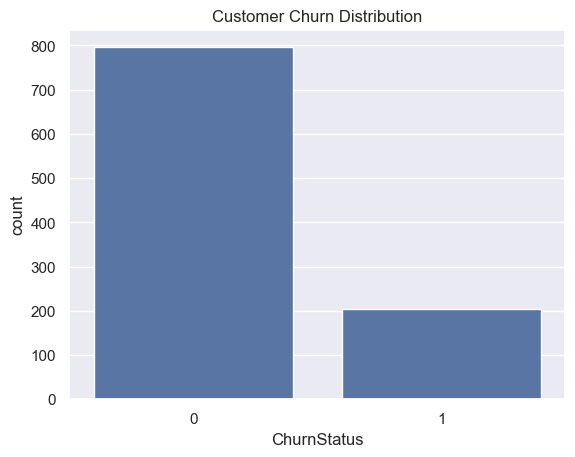

In [115]:
sns.countplot(x='ChurnStatus', data=merged_df)

plt.title('Customer Churn Distribution')

plt.show()

<h2> LOGIN FREQUENCY VS CHURN

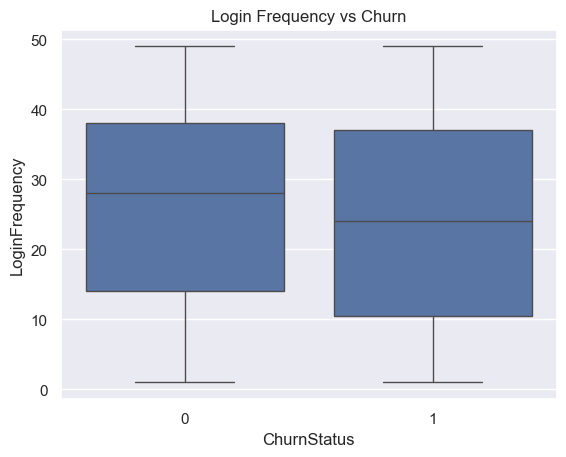

In [116]:
sns.boxplot(x='ChurnStatus',y='LoginFrequency', data=merged_df)
plt.title('Login Frequency vs Churn')

plt.show()

<h2>TOTAL SPENDING VS CHURN

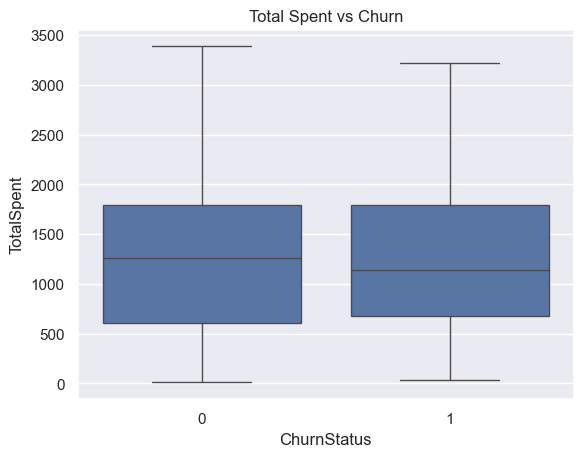

In [117]:
sns.boxplot(x='ChurnStatus',y='TotalSpent', data=merged_df)
plt.title('Total Spent vs Churn')

plt.show()

<h2> COMPLAINT COUNT VS CHURN

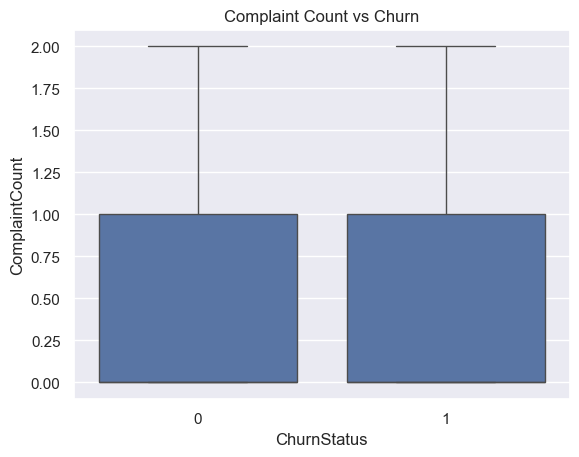

In [118]:
sns.boxplot(
    x='ChurnStatus',
    y='ComplaintCount',
    data=merged_df
)
plt.title('Complaint Count vs Churn')
plt.show()


<h2> UNRESOLVED COMPLAINTS VS CHURN

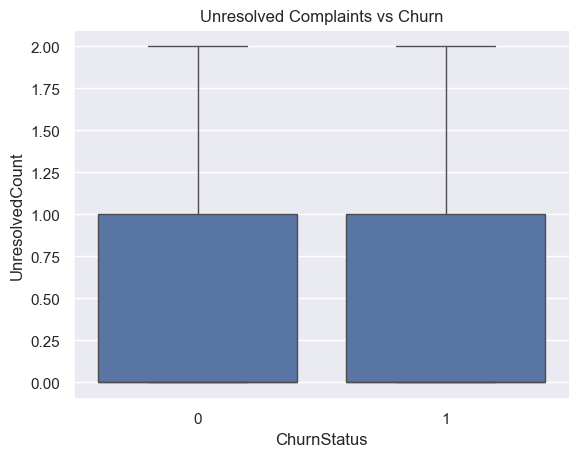

In [119]:
sns.boxplot(
    x='ChurnStatus',
    y='UnresolvedCount',
    data=merged_df
)

plt.title('Unresolved Complaints vs Churn')

plt.show()

<h2> CORRELATION HEATMAP

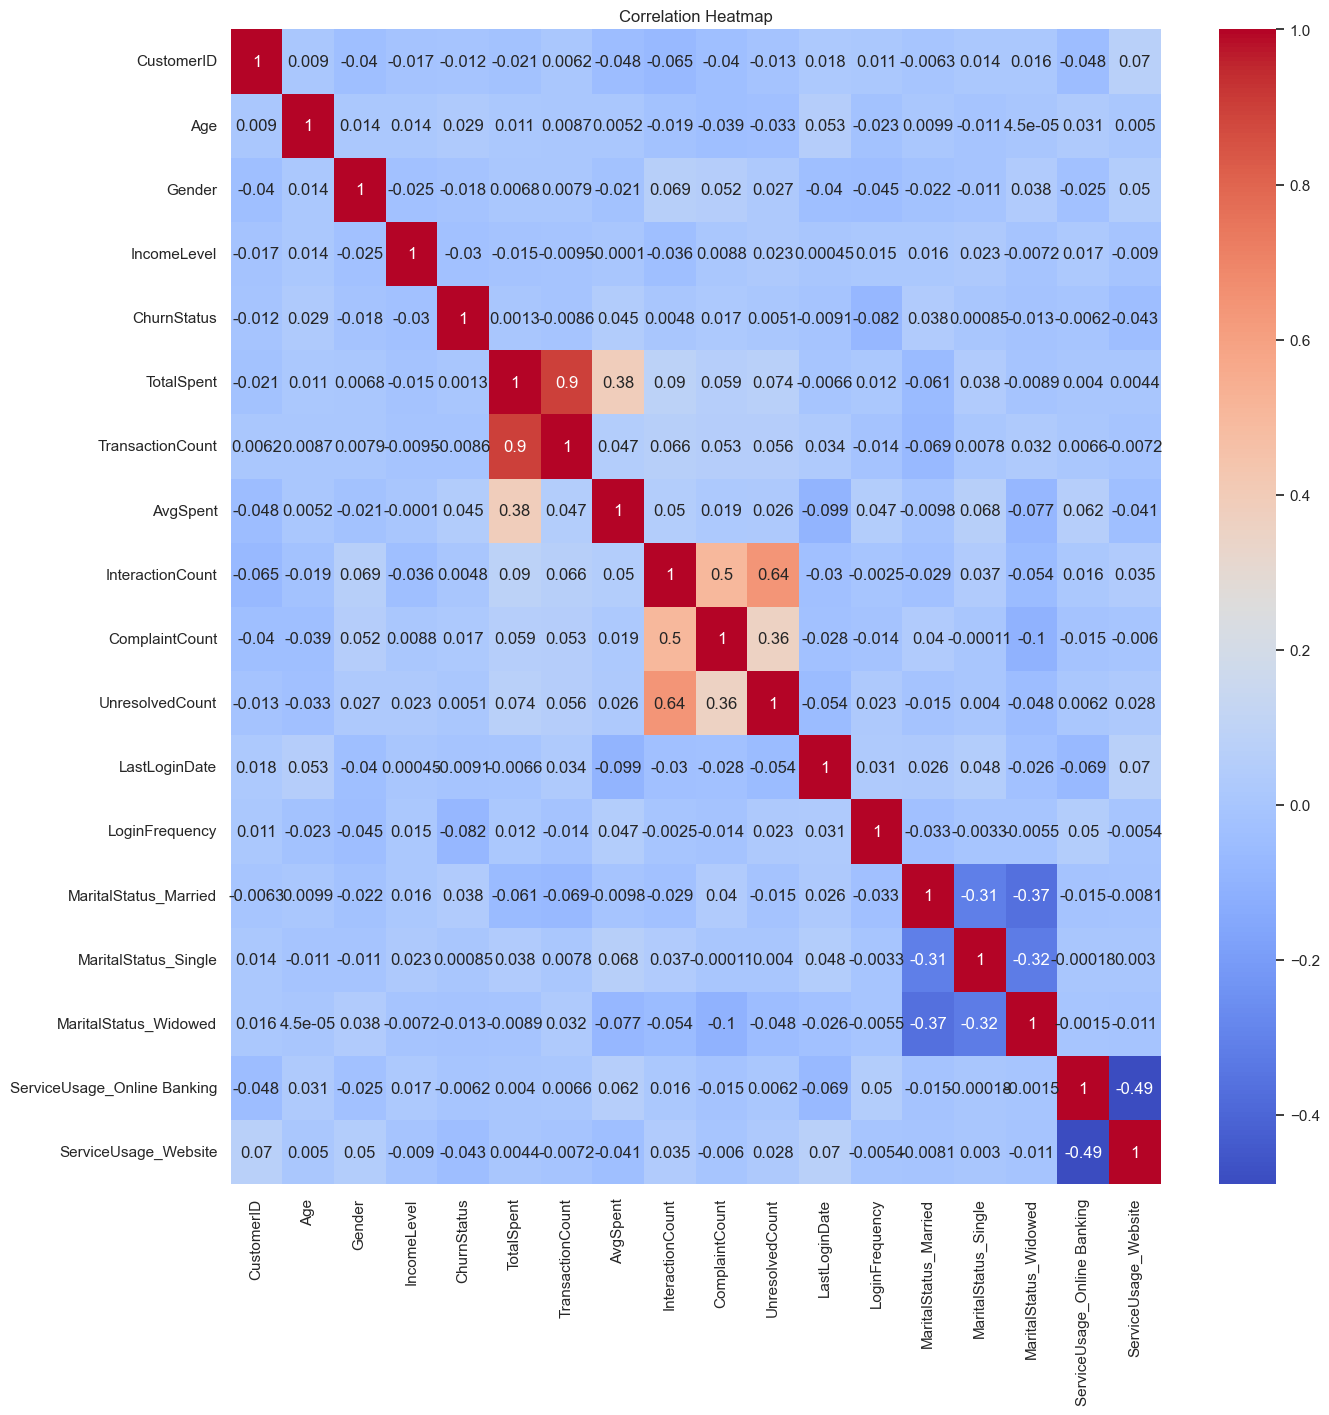

In [134]:
plt.figure(figsize=(15,15))

sns.heatmap(model_df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.show()

<h1>Model

<h2>Split the Dataset

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [122]:
x = model_df.drop(['ChurnStatus','CustomerID','LastLoginDate'], axis=1)
y = model_df['ChurnStatus']

In [123]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=47,stratify=y)

<h2>Random Forest

In [124]:
model_rf = RandomForestClassifier(n_estimators=100,max_depth =  10, random_state=47)
model_rf.fit(x_train,y_train)
model_rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [125]:
y_pred = model_rf.predict(x_test)
y_prob = model_rf.predict_proba(x_test)[:,1]

<h1> Evaluation

In [126]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

C:\Users\sankp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [127]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.795
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5414940941862249


In [128]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[159   0]
 [ 41   0]]


<h1>Visualizations

<h2>Churn Distribution

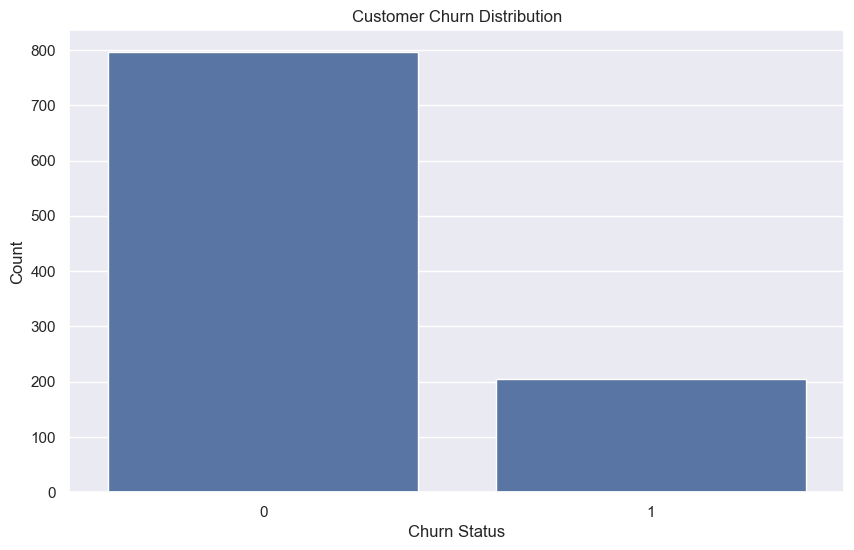

In [129]:
plt.figure(figsize=(10,6))

sns.countplot(x=y)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

<h2>Confusion Matrix

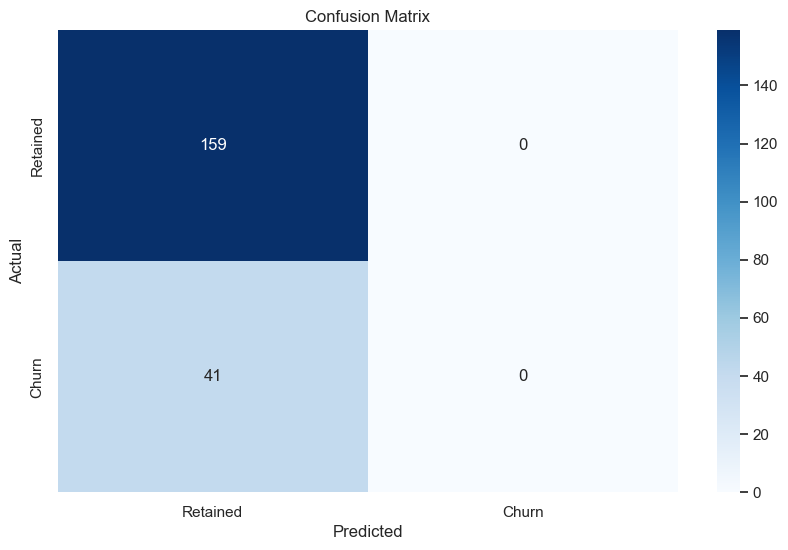

In [130]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained', 'Churn'],
    yticklabels=['Retained', 'Churn']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<h2>Feature Importance

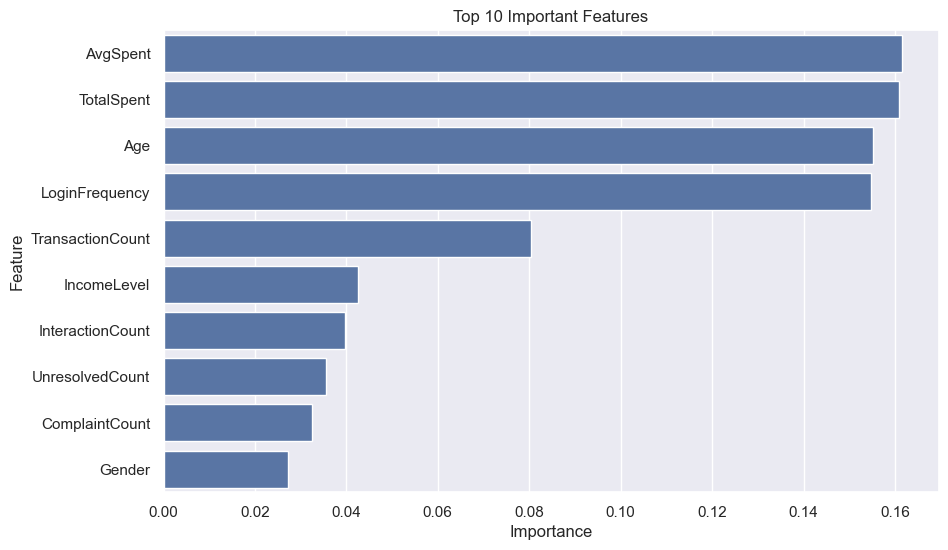

In [131]:
feature_importance = model_rf.feature_importances_

importance_df = pd.DataFrame({'Feature': x.columns,'Importance': feature_importance})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x='Importance', y='Feature',data=importance_df.head(10))

plt.title("Top 10 Important Features")

plt.show()


<h2>Model Performance

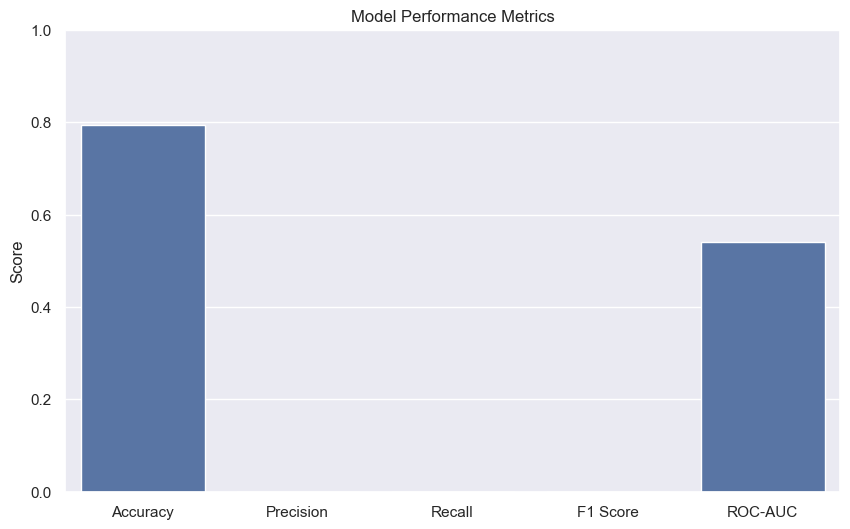

In [132]:
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC-AUC': roc_auc
}

plt.figure(figsize=(10,6))

sns.barplot(x=list(metrics.keys()), y=list(metrics.values()))

plt.ylim(0,1)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()
plt.show()


<h1>Results

<h2>Model Performance

In [133]:
print(f"Accuracy: {metrics['Accuracy']:.2f} %")
print(f"Precision: {metrics['Precision']:.2f} %")
print(f"Recall: {metrics['Recall']:.2f} %")
print(f"F1 Score: {metrics['F1 Score']:.2f} %")
print(f"ROC AUC: {metrics['ROC-AUC']:.2f} %")


Accuracy: 0.80 %
Precision: 0.00 %
Recall: 0.00 %
F1 Score: 0.00 %
ROC AUC: 0.54 %


<h1>Interpretation

<ol>
<li>Accuracy shows overall prediction correctness
<li>Precision indicates how many predicted churn customers actually churned
<li>Recall indicates how many actually churned customers were correctly identified
<li>F1 score balances Precision and Recall
<li>ROC-AUC measures how effectively the model separates churn and non_churn customers

<h1>Conclusion

The Random Forest Classification model was successfully
used to predict customer churn.

The model helps identify high-risk customers and supports
business decision-making for customer retention strategies.

Further improvements can be achieved through:
- balancing the dataset
- feature engineering
- advanced ensemble models
- threshold optimization